# Topology Reward Analysis

Generate molecules for the topology GRPO checkpoint, then score and inspect all reward submetrics: MCS, transformed MCS, Murcko scaffold, fingerprint blend, and size penalty.

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / "configs").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))
os.environ.setdefault("PROJECT_ROOT", str(ROOT))

ROOT

PosixPath('/network/scratch/g/goldszaa/chemflow')

## Generate Samples

Run this once from the repository root if the sample bundle does not exist yet:

```bash
python -m rl.experiments.topology.generate_topology_grpo_samples --n_mols 300
```

In [2]:
RL_STEM = "grpo_topology_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_hydra_continue_maxa100-omitposkl_scaff_b10_p0p5_w50_canonsmi_best"
SAMPLES_PT = ROOT / "rl" / "experiments" / "topology" / RL_STEM / "topology_grpo_samples.pt"
OUT_DIR = SAMPLES_PT.parent

print(SAMPLES_PT)
if not SAMPLES_PT.exists():
    print("Missing sample bundle. Generate it with:")
    print("python -m rl.experiments.topology.generate_topology_grpo_samples --n_mols 300")

/network/scratch/g/goldszaa/chemflow/rl/experiments/topology/grpo_topology_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_hydra_continue_maxa100-omitposkl_scaff_b10_p0p5_w50_canonsmi_best/topology_grpo_samples.pt


In [3]:
import pandas as pd
import torch
from rdkit import Chem
from rdkit.Chem import Draw, rdDepictor

from rl.rewards import _SHAPE_REF_SMILES, _heavy_atom_mol, _score_topology_single

bundle = torch.load(SAMPLES_PT, map_location="cpu", weights_only=False)
atom_tokens = bundle["vocab"]["atom_tokens"]
edge_tokens = bundle["vocab"]["edge_tokens"]
charge_tokens = bundle["vocab"]["charge_tokens"]

print("loaded:", SAMPLES_PT)
print("meta:", bundle.get("meta", {}))
print("base valid:", len(bundle["base"].get("valid_mols", [])))
print("rl valid:", len(bundle["rl"].get("valid_mols", [])))

/home/mila/g/goldszaa/scratch/chemflow/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loaded: /network/scratch/g/goldszaa/chemflow/rl/experiments/topology/grpo_topology_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_hydra_continue_maxa100-omitposkl_scaff_b10_p0p5_w50_canonsmi_best/topology_grpo_samples.pt
meta: {'pretrained_ckpt': '/network/scratch/g/goldszaa/chemflow/.pretrained_model/epoch=499-step=48500.ckpt', 'rl_ckpt': '/network/scratch/g/goldszaa/chemflow/.rl_ckpts/grpo_topology_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_hydra_continue_maxa100-omitposkl_scaff_b10_p0p5_w50_canonsmi_best.pt', 'n_mols_requested': 300, 'integrator_max_atoms': 100, 'hydra_overrides': ['data.datamodule.batch_size.test=128']}
base valid: 300
rl valid: 300


In [4]:
WEIGHTS = {
    "weighted_mcs": 0.45,
    "weighted_scaffold": 0.25,
    "weighted_fp": 0.20,
    "weighted_size": 0.10,
}

def final_rdkit(traj):
    return traj[-1].to_rdkit_mol(atom_tokens, edge_tokens, charge_tokens)

def canonical_heavy_smiles(rd):
    return Chem.MolToSmiles(_heavy_atom_mol(rd), canonical=True)

def score_rdkit(rd):
    reward, mcs, mcs_t, scaffold, fp, size = _score_topology_single(rd)
    return {
        "reward": reward,
        "mcs": mcs,
        "mcs_t": mcs_t,
        "scaffold": scaffold,
        "fp": fp,
        "size": size,
        "weighted_mcs": 0.45 * mcs_t,
        "weighted_scaffold": 0.25 * scaffold,
        "weighted_fp": 0.20 * fp,
        "weighted_size": 0.10 * size,
    }

def score_split(split_name):
    rows = []
    for idx, traj in enumerate(bundle[split_name].get("valid_mols", [])):
        rd = final_rdkit(traj)
        if rd is None:
            continue
        try:
            heavy = _heavy_atom_mol(rd)
            scored = score_rdkit(rd)
            rows.append({
                "split": split_name,
                "idx": idx,
                **scored,
                "n_atoms": int(rd.GetNumAtoms()),
                "heavy_atoms": int(heavy.GetNumHeavyAtoms()),
                "heavy_smiles": canonical_heavy_smiles(rd),
                "explicit_smiles": Chem.MolToSmiles(rd, canonical=True),
                "mol": rd,
            })
        except Exception as exc:
            print(f"skip {split_name} idx={idx}: {exc}")
    return rows

rows = score_split("base") + score_split("rl")
df_all = pd.DataFrame(rows)
if df_all.empty:
    raise RuntimeError("No valid molecules could be converted and scored.")

df_unique = (
    df_all.sort_values("reward", ascending=False)
    .drop_duplicates(["split", "heavy_smiles"], keep="first")
    .reset_index(drop=True)
)
df_rl_unique = df_unique[df_unique["split"] == "rl"].copy().reset_index(drop=True)

print(f"scored={len(df_all)} unique={len(df_unique)} rl_unique={len(df_rl_unique)}")
display(df_rl_unique[["idx", "reward", "mcs", "mcs_t", "scaffold", "fp", "size", "heavy_atoms", "heavy_smiles"]].head(20))

scored=600 unique=552 rl_unique=252


,idx,reward,mcs,mcs_t,scaffold,fp,size,heavy_atoms,heavy_smiles
0,64,0.805932,0.6250,0.937027,1.0,0.260059,0.822578,13,CCNc1c(C)cc(O)c(O)c1N
1,131,0.801512,0.6250,0.937027,1.0,0.295925,0.706648,12,CCNc1ccc(C)c(N)c1C
2,16,0.800794,0.6250,0.937027,1.0,0.292336,0.706648,12,CCNc1cc(N)c(C)cc1C
3,33,0.800764,0.6250,0.937027,1.0,0.234221,0.822578,13,CCN(C)c1cc(C)cc(N)c1C
4,285,0.799882,0.6250,0.937027,1.0,0.287774,0.706648,12,CCNc1c(O)ccc(C)c1C
5,111,0.799695,0.6250,0.937027,1.0,0.349531,0.581273,11,CCNc1c(C)cccc1C
6,275,0.798731,0.6250,0.937027,1.0,0.282022,0.706648,12,CCNc1c(C)ccc(N)c1N
7,199,0.797713,0.6250,0.937027,1.0,0.276930,0.706648,12,CCNc1c(N)ccc(N)c1C
8,223,0.774812,0.5625,0.875447,1.0,0.243014,0.822578,13,CNc1cc(C)c(N)c(NC)c1C
9,86,0.773288,0.5625,0.875447,1.0,0.235398,0.822578,13,CCc1c(C)c(NC)cc(N)c1N


In [5]:
OUT_DIR.mkdir(parents=True, exist_ok=True)
csv_cols = [c for c in df_all.columns if c != "mol"]
all_csv = OUT_DIR / "topology_scores_all.csv"
unique_csv = OUT_DIR / "topology_scores_unique.csv"
df_all[csv_cols].to_csv(all_csv, index=False)
df_unique[csv_cols].to_csv(unique_csv, index=False)
print("saved:", all_csv)
print("saved:", unique_csv)

saved: /network/scratch/g/goldszaa/chemflow/rl/experiments/topology/grpo_topology_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_hydra_continue_maxa100-omitposkl_scaff_b10_p0p5_w50_canonsmi_best/topology_scores_all.csv
saved: /network/scratch/g/goldszaa/chemflow/rl/experiments/topology/grpo_topology_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_hydra_continue_maxa100-omitposkl_scaff_b10_p0p5_w50_canonsmi_best/topology_scores_unique.csv


PosixPath('/network/scratch/g/goldszaa/chemflow/rl/experiments/topology/grpo_topology_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_hydra_continue_maxa100-omitposkl_scaff_b10_p0p5_w50_canonsmi_best/topology_metric_histograms.png')

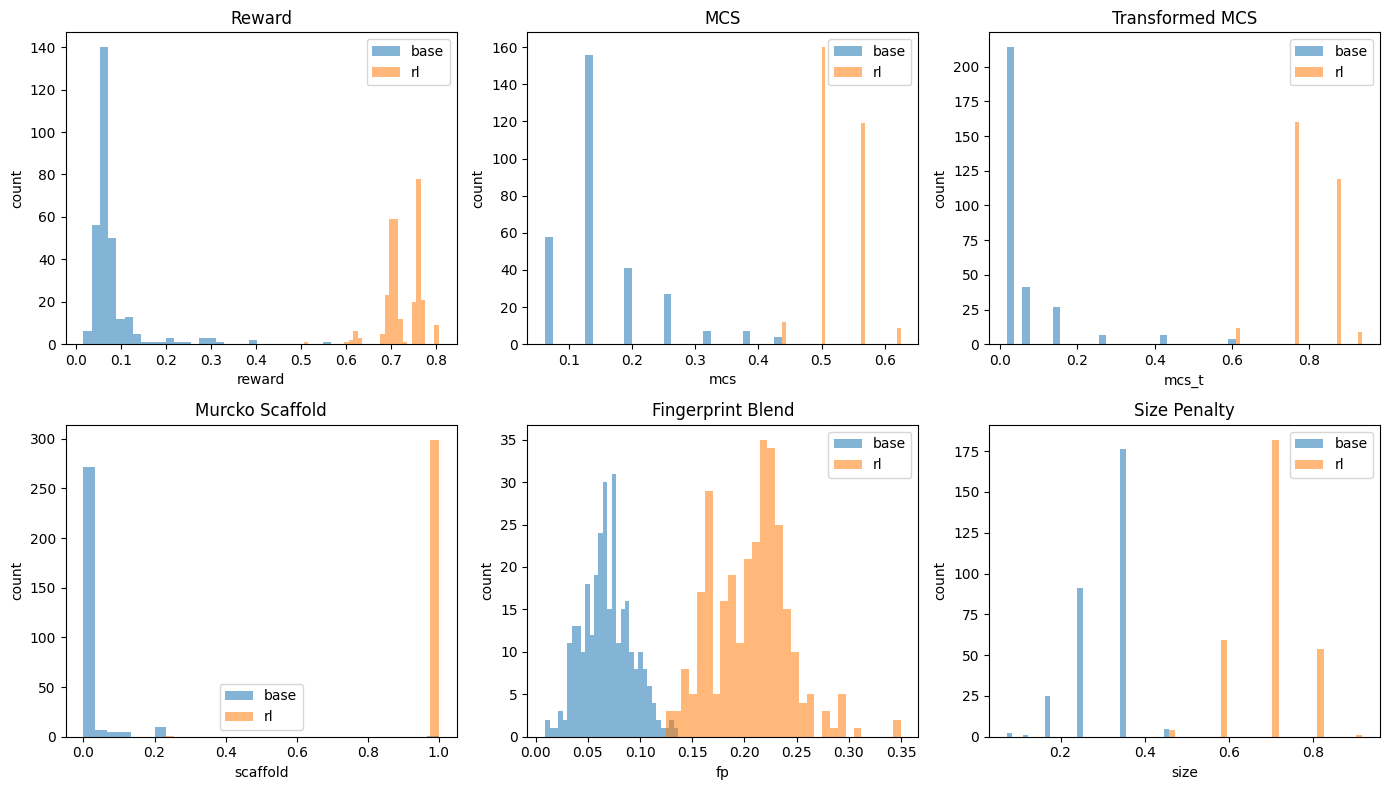

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

metric_cols = ["reward", "mcs", "mcs_t", "scaffold", "fp", "size"]
titles = ["Reward", "MCS", "Transformed MCS", "Murcko Scaffold", "Fingerprint Blend", "Size Penalty"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col, title in zip(axes.ravel(), metric_cols, titles):
    for split, sub in df_all.groupby("split"):
        ax.hist(sub[col], bins=30, alpha=0.55, label=split)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    ax.legend()
fig.tight_layout()
hist_png = OUT_DIR / "topology_metric_histograms.png"
fig.savefig(hist_png, dpi=180)
hist_png

PosixPath('/network/scratch/g/goldszaa/chemflow/rl/experiments/topology/grpo_topology_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_hydra_continue_maxa100-omitposkl_scaff_b10_p0p5_w50_canonsmi_best/topology_component_scatter.png')

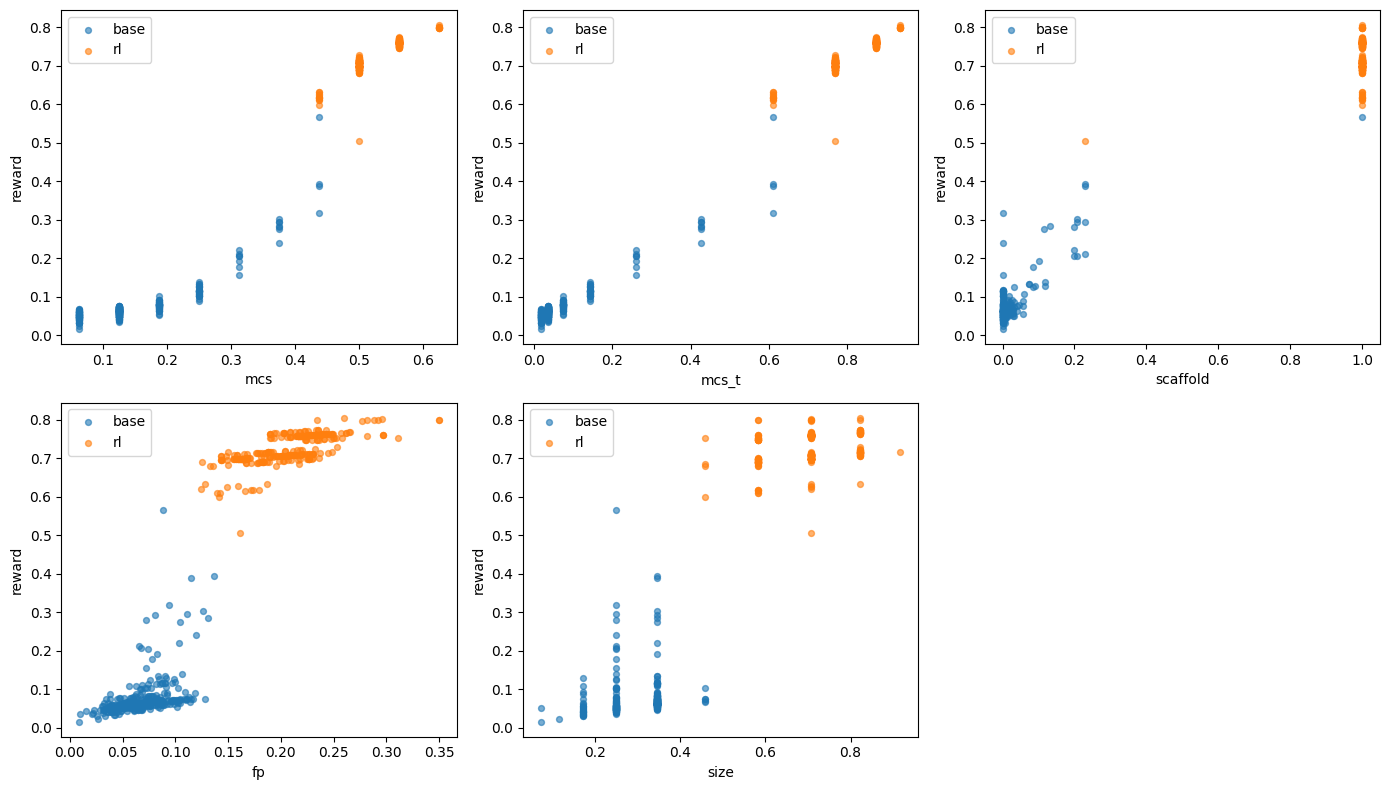

In [7]:
component_cols = ["mcs", "mcs_t", "scaffold", "fp", "size"]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), component_cols):
    for split, sub in df_all.groupby("split"):
        ax.scatter(sub[col], sub["reward"], s=18, alpha=0.6, label=split)
    ax.set_xlabel(col)
    ax.set_ylabel("reward")
    ax.legend()
axes.ravel()[-1].axis("off")
fig.tight_layout()
scatter_png = OUT_DIR / "topology_component_scatter.png"
fig.savefig(scatter_png, dpi=180)
scatter_png

,weighted_mcs,weighted_scaffold,weighted_fp,weighted_size
split,,,,
base,0.030867,0.004843,0.013698,0.030107
rl,0.364355,0.249357,0.041291,0.070024


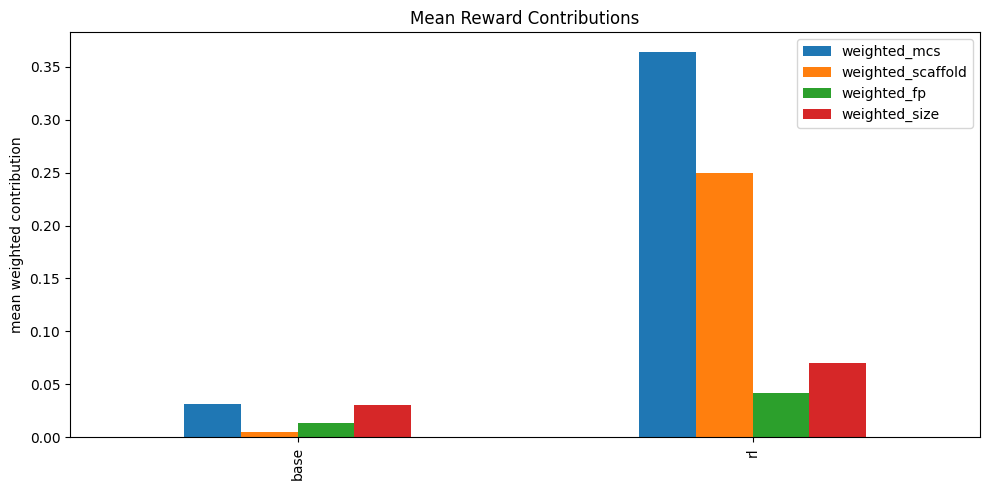

In [8]:
weighted_cols = ["weighted_mcs", "weighted_scaffold", "weighted_fp", "weighted_size"]
weighted_means = df_all.groupby("split")[weighted_cols].mean()
ax = weighted_means.plot(kind="bar", figsize=(10, 5))
ax.set_ylabel("mean weighted contribution")
ax.set_xlabel("")
ax.set_title("Mean Reward Contributions")
fig = ax.get_figure()
fig.tight_layout()
weighted_png = OUT_DIR / "topology_weighted_contributions.png"
fig.savefig(weighted_png, dpi=180)
weighted_means

In [9]:
TOP_K = 20
top = df_rl_unique.head(TOP_K).copy()
top.insert(0, "rank", range(1, len(top) + 1))
top_csv = OUT_DIR / f"top{TOP_K}_topology_unique.csv"
top[[c for c in top.columns if c != "mol"]].to_csv(top_csv, index=False)

top_cols = [
    "rank", "idx", "reward", "weighted_mcs", "weighted_scaffold",
    "weighted_fp", "weighted_size", "mcs", "mcs_t", "scaffold", "fp",
    "size", "heavy_atoms", "heavy_smiles",
]
display(top[top_cols])
print(top[top_cols].to_string(index=False))
print("saved:", top_csv)

,rank,idx,reward,weighted_mcs,weighted_scaffold,weighted_fp,weighted_size,mcs,mcs_t,scaffold,fp,size,heavy_atoms,heavy_smiles
0,1,64,0.805932,0.421662,0.25,0.052012,0.082258,0.6250,0.937027,1.0,0.260059,0.822578,13,CCNc1c(C)cc(O)c(O)c1N
1,2,131,0.801512,0.421662,0.25,0.059185,0.070665,0.6250,0.937027,1.0,0.295925,0.706648,12,CCNc1ccc(C)c(N)c1C
2,3,16,0.800794,0.421662,0.25,0.058467,0.070665,0.6250,0.937027,1.0,0.292336,0.706648,12,CCNc1cc(N)c(C)cc1C
3,4,33,0.800764,0.421662,0.25,0.046844,0.082258,0.6250,0.937027,1.0,0.234221,0.822578,13,CCN(C)c1cc(C)cc(N)c1C
4,5,285,0.799882,0.421662,0.25,0.057555,0.070665,0.6250,0.937027,1.0,0.287774,0.706648,12,CCNc1c(O)ccc(C)c1C
5,6,111,0.799695,0.421662,0.25,0.069906,0.058127,0.6250,0.937027,1.0,0.349531,0.581273,11,CCNc1c(C)cccc1C
6,7,275,0.798731,0.421662,0.25,0.056404,0.070665,0.6250,0.937027,1.0,0.282022,0.706648,12,CCNc1c(C)ccc(N)c1N
7,8,199,0.797713,0.421662,0.25,0.055386,0.070665,0.6250,0.937027,1.0,0.276930,0.706648,12,CCNc1c(N)ccc(N)c1C
8,9,223,0.774812,0.393951,0.25,0.048603,0.082258,0.5625,0.875447,1.0,0.243014,0.822578,13,CNc1cc(C)c(N)c(NC)c1C
9,10,86,0.773288,0.393951,0.25,0.047080,0.082258,0.5625,0.875447,1.0,0.235398,0.822578,13,CCc1c(C)c(NC)cc(N)c1N


 rank  idx   reward  weighted_mcs  weighted_scaffold  weighted_fp  weighted_size    mcs    mcs_t  scaffold       fp     size  heavy_atoms            heavy_smiles
    1   64 0.805932      0.421662               0.25     0.052012       0.082258 0.6250 0.937027       1.0 0.260059 0.822578           13   CCNc1c(C)cc(O)c(O)c1N
    2  131 0.801512      0.421662               0.25     0.059185       0.070665 0.6250 0.937027       1.0 0.295925 0.706648           12      CCNc1ccc(C)c(N)c1C
    3   16 0.800794      0.421662               0.25     0.058467       0.070665 0.6250 0.937027       1.0 0.292336 0.706648           12      CCNc1cc(N)c(C)cc1C
    4   33 0.800764      0.421662               0.25     0.046844       0.082258 0.6250 0.937027       1.0 0.234221 0.822578           13   CCN(C)c1cc(C)cc(N)c1C
    5  285 0.799882      0.421662               0.25     0.057555       0.070665 0.6250 0.937027       1.0 0.287774 0.706648           12      CCNc1c(O)ccc(C)c1C
    6  111 0.799695      0.4

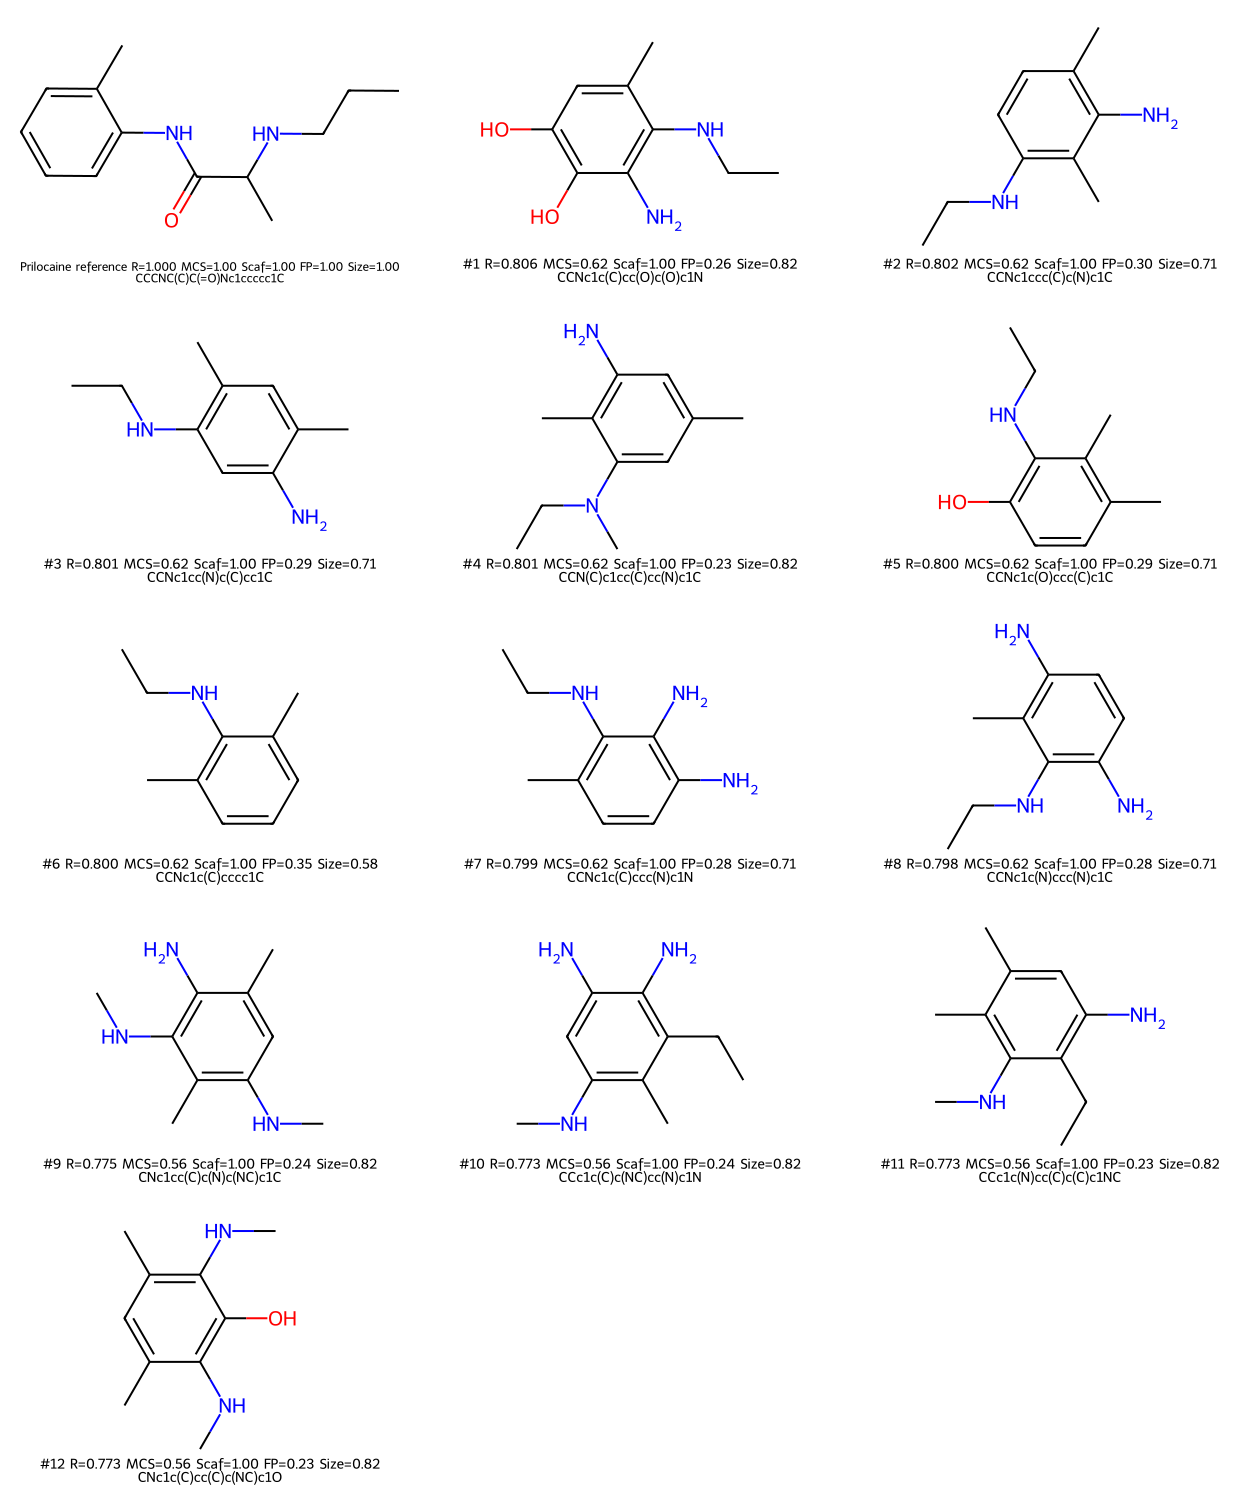

PosixPath('/network/scratch/g/goldszaa/chemflow/rl/experiments/topology/grpo_topology_seed0_sig0p05_g8_mu2_kl0.02_lr1e-4_hydra_continue_maxa100-omitposkl_scaff_b10_p0p5_w50_canonsmi_best/top12_topology_unique_with_prilocaine.png')

In [10]:
grid_top = top.head(12)
ref_mol = _heavy_atom_mol(Chem.MolFromSmiles(_SHAPE_REF_SMILES))
ref_scores = score_rdkit(ref_mol)
ref_depict = Chem.Mol(ref_mol)
rdDepictor.Compute2DCoords(ref_depict, canonOrient=True, clearConfs=True)

def depiction_copy(mol, template):
    m = Chem.Mol(mol)
    try:
        rdDepictor.GenerateDepictionMatching2DStructure(
            m,
            template,
            acceptFailure=True,
        )
    except Exception:
        rdDepictor.Compute2DCoords(m, canonOrient=True, clearConfs=True)
    return m

mols = [ref_depict] + [
    depiction_copy(_heavy_atom_mol(row["mol"]), ref_depict)
    for _, row in grid_top.iterrows()
]
legends = [
    f"Prilocaine reference R={ref_scores['reward']:.3f} "
    f"MCS={ref_scores['mcs']:.2f} Scaf={ref_scores['scaffold']:.2f} "
    f"FP={ref_scores['fp']:.2f} Size={ref_scores['size']:.2f}\n"
    f"{Chem.MolToSmiles(ref_mol, canonical=True)}"
]
for _, row in grid_top.iterrows():
    legends.append(
        f"#{int(row['rank'])} R={row['reward']:.3f} "
        f"MCS={row['mcs']:.2f} Scaf={row['scaffold']:.2f} "
        f"FP={row['fp']:.2f} Size={row['size']:.2f}\n"
        f"{row['heavy_smiles']}"
    )

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(420, 300),
    legends=legends,
    useSVG=False,
)
grid_png = OUT_DIR / "top12_topology_unique_with_prilocaine.png"
display(img)
grid_png